# Supplemental Figure 7

In [1]:
suppressPackageStartupMessages(library(dplyr))
suppressPackageStartupMessages(library(ggplot2))
suppressPackageStartupMessages(library(patchwork))
suppressPackageStartupMessages(library(arrow))
suppressPackageStartupMessages(library(RColorBrewer))

Warning message:
“package ‘dplyr’ was built under R version 4.2.3”
Warning message:
“package ‘ggplot2’ was built under R version 4.2.3”
Warning message:
“package ‘patchwork’ was built under R version 4.2.3”
Warning message:
“package ‘arrow’ was built under R version 4.2.3”
Warning message:
“package ‘RColorBrewer’ was built under R version 4.2.3”


In [2]:
figure_dir <- "../figures/supplementary"
output_supp_figure_7 <- file.path(
    figure_dir, "supp_figure_7_log_reg_pr_curves.png"
)
results_dir <- file.path(
    "./pr_results"
)

In [3]:
# Load data
PR_results_file <- file.path(results_dir, "pr_curve_all_plates.parquet")

PR_results_df <- arrow::read_parquet(PR_results_file)

dim(PR_results_df)
head(PR_results_df)

[1] 50162     7

model,split,precision,recall,threshold,plate,institution
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
final,train,0.4997616,1,5.438197e-07,ALL,ALL
final,train,0.4997914,1,8.835875e-07,ALL,ALL
final,train,0.4998212,1,6.761500e-06,ALL,ALL
final,train,0.4998510,1,8.327423e-06,ALL,ALL
final,train,0.4998808,1,2.239646e-05,ALL,ALL
final,train,0.4999106,1,2.725798e-05,ALL,ALL


## Generate PR curve for test/train/holdout splits from all plates

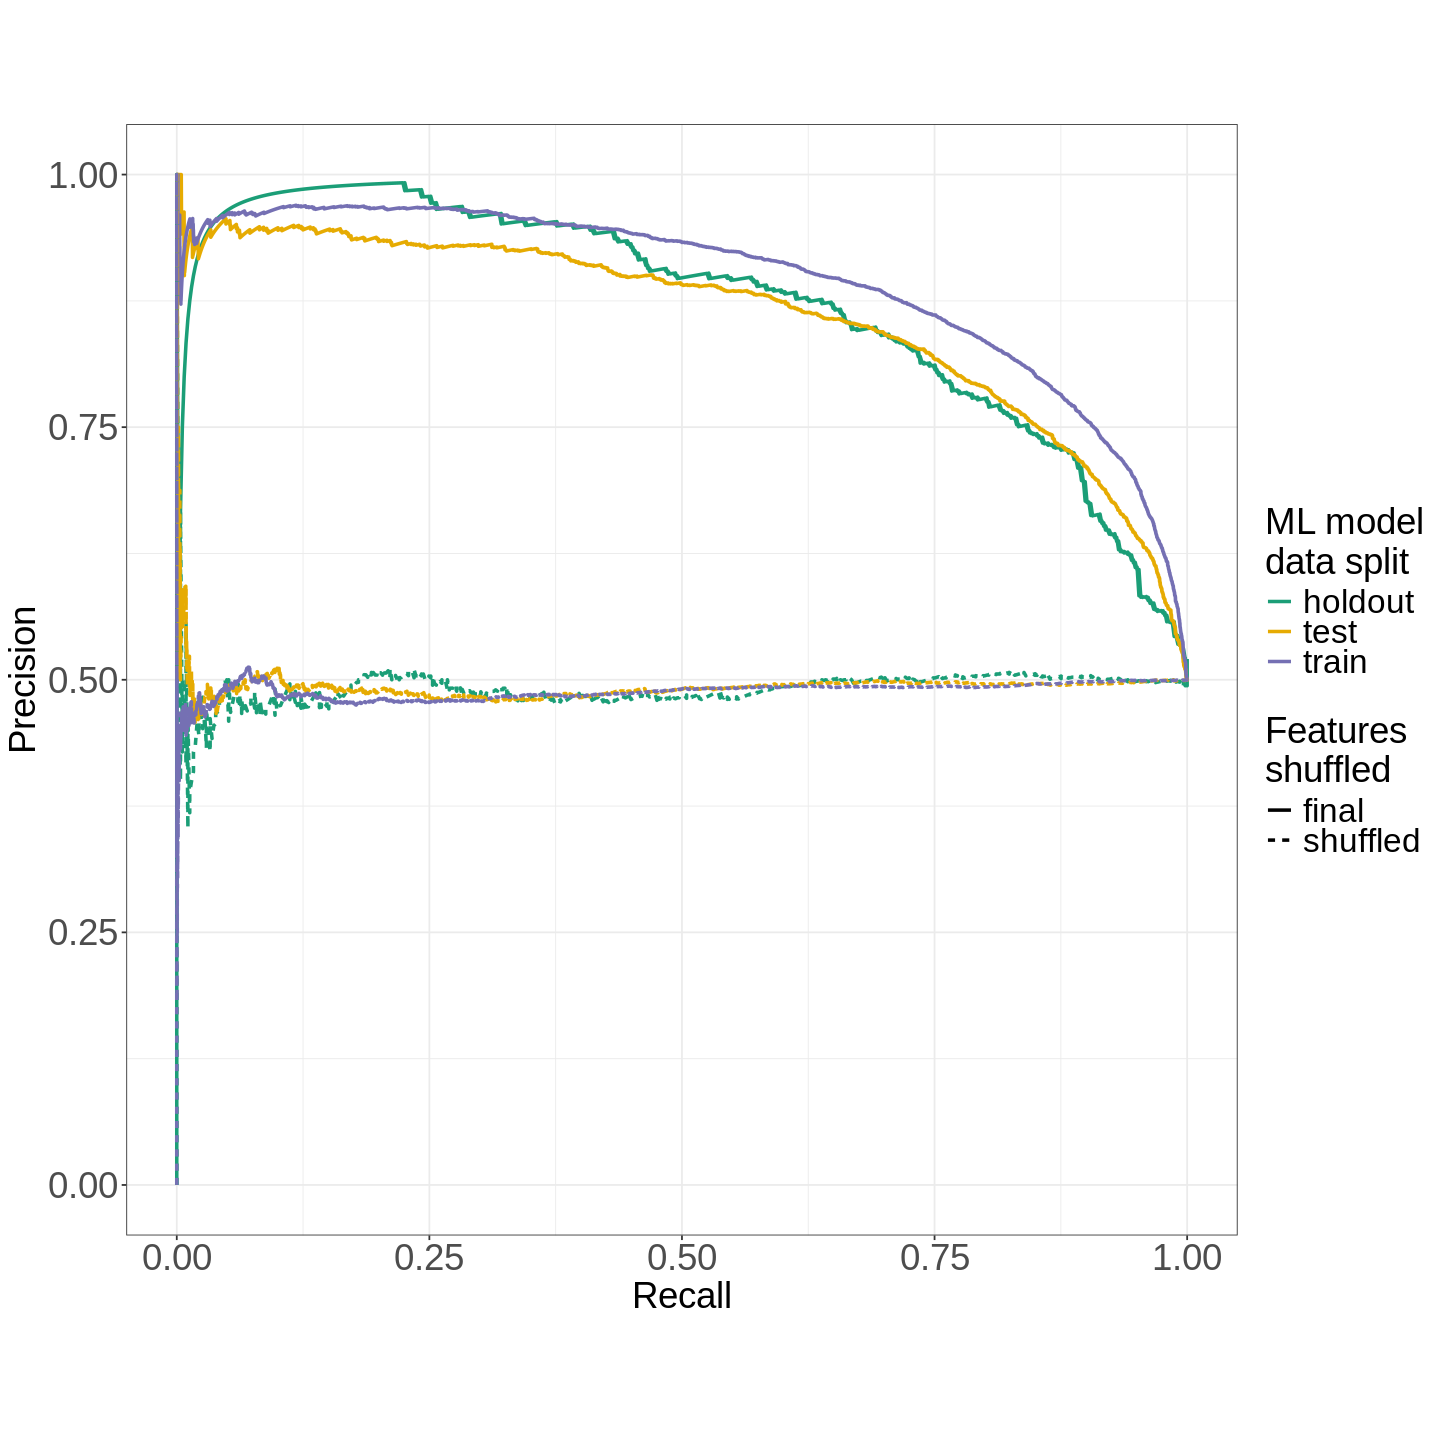

In [4]:
width <- 12
height <- 12
options(repr.plot.width = width, repr.plot.height = height)
pr_train_test_plot <- (
    ggplot(PR_results_df, aes(x = recall, y = precision, color = split, linetype = model))
    + geom_line(aes(linetype = model), linewidth = 1)
    + theme_bw()
    + coord_fixed()
    + labs(color = "ML model\ndata split", linetype = "Features\nshuffled", x = "Recall", y = "Precision")
    # change the colors
    + scale_color_manual(values = c(
        "test" = brewer.pal(8, "Dark2")[6],
        "train" = brewer.pal(8, "Dark2")[3],
        "holdout" = brewer.pal(8, "Dark2")[1]
    ))
    + scale_y_continuous(limits = c(0, 1))
    # change the line thickness of the lines in the legend
    + guides(linetype = guide_legend(override.aes = list(size = 1)))  
    # change the text size
    + theme(
        # x and y axis text size
        axis.text.x = element_text(size = 22),
        axis.text.y = element_text(size = 22),
        # x and y axis title size
        axis.title.x = element_text(size = 22),
        axis.title.y = element_text(size = 22),
        # legend text size
        legend.text = element_text(size = 20),
        legend.title = element_text(size = 22),
    )
)

pr_train_test_plot

In [5]:
# Load data
PR_results_file <- file.path(results_dir, "pr_curve_per_plate.parquet")

PR_results_df <- arrow::read_parquet(PR_results_file)

# Update plate names
PR_results_df <- PR_results_df %>%
    mutate(
        plate = recode(
            plate,
            "Plate_3" = "Plate_A",
            "Plate_3_prime" = "Plate_B",
            "Plate_5" = "Plate_C",
            "Plate_6" = "Plate_D"
        )
    )

dim(PR_results_df)
head(PR_results_df)

[1] 50180     7

model,split,precision,recall,threshold,plate,institution
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
final,train,0.4523432,1,5.438197e-07,Plate_A,ALL
final,train,0.4524084,1,6.761500e-06,Plate_A,ALL
final,train,0.4524737,1,8.327423e-06,Plate_A,ALL
final,train,0.4525389,1,4.487067e-05,Plate_A,ALL
final,train,0.4526042,1,6.559921e-05,Plate_A,ALL
final,train,0.4526696,1,8.869114e-05,Plate_A,ALL


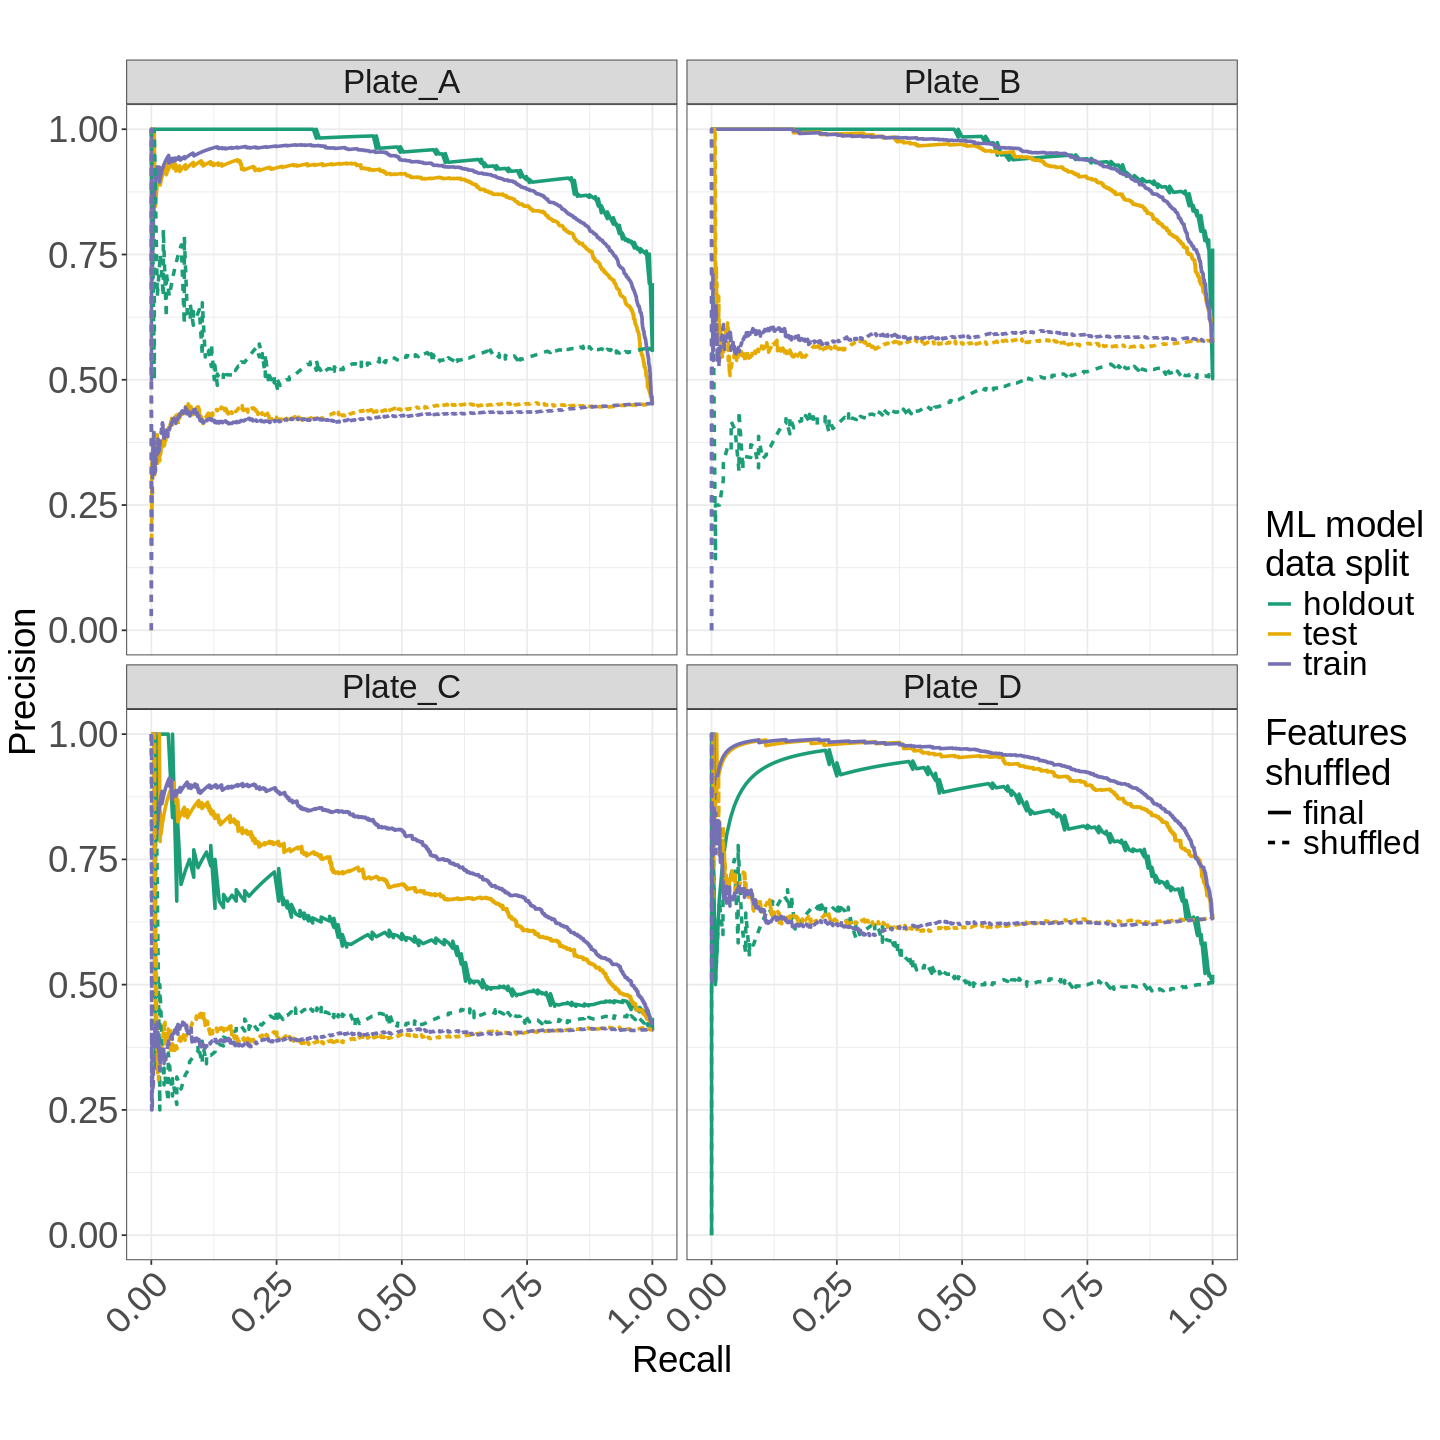

In [6]:
width <- 12
height <- 12
options(repr.plot.width = width, repr.plot.height = height)
pr_per_plate_plot <- (
    ggplot(PR_results_df, aes(x = recall, y = precision, color = split, linetype = model))
    + geom_line(aes(linetype = model), linewidth = 1)
    + theme_bw()
    + coord_fixed()
    + facet_wrap(~ plate, ncol = 2)
    + labs(color = "ML model\ndata split", linetype = "Features\nshuffled", x = "Recall", y = "Precision")
    # change the colors
    + scale_color_manual(values = c(
        "test" = brewer.pal(8, "Dark2")[6],
        "train" = brewer.pal(8, "Dark2")[3],
        "holdout" = brewer.pal(8, "Dark2")[1]
    ))
    + scale_y_continuous(limits = c(0, 1))
    # change the line thickness of the lines in the legend
    + guides(linetype = guide_legend(override.aes = list(size = 1)))  
    # change the text size
    + theme(
        # x and y axis text size
        axis.text.x = element_text(size = 22, angle = 45, hjust = 1),
        axis.text.y = element_text(size = 22),
        # x and y axis title size
        axis.title.x = element_text(size = 22),
        axis.title.y = element_text(size = 22),
        # legend text size
        legend.text = element_text(size = 20),
        legend.title = element_text(size = 22),
        # strip text size for facets
        strip.text = element_text(size = 20)
    )
)

pr_per_plate_plot

In [7]:
# Load data
PR_results_file <- file.path(results_dir, "pr_curve_plate6_per_institution.parquet")

PR_results_df <- arrow::read_parquet(PR_results_file)

dim(PR_results_df)
head(PR_results_df)

[1] 2486    7

model,split,precision,recall,threshold,plate,institution
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
final,test,0.6076433,1,0.0008201027,Plate_6,MGH
final,test,0.6084184,1,0.0010972571,Plate_6,MGH
final,test,0.6091954,1,0.0015132713,Plate_6,MGH
final,test,0.6099744,1,0.0020874755,Plate_6,MGH
final,test,0.6107554,1,0.0026749489,Plate_6,MGH
final,test,0.6115385,1,0.0031830481,Plate_6,MGH


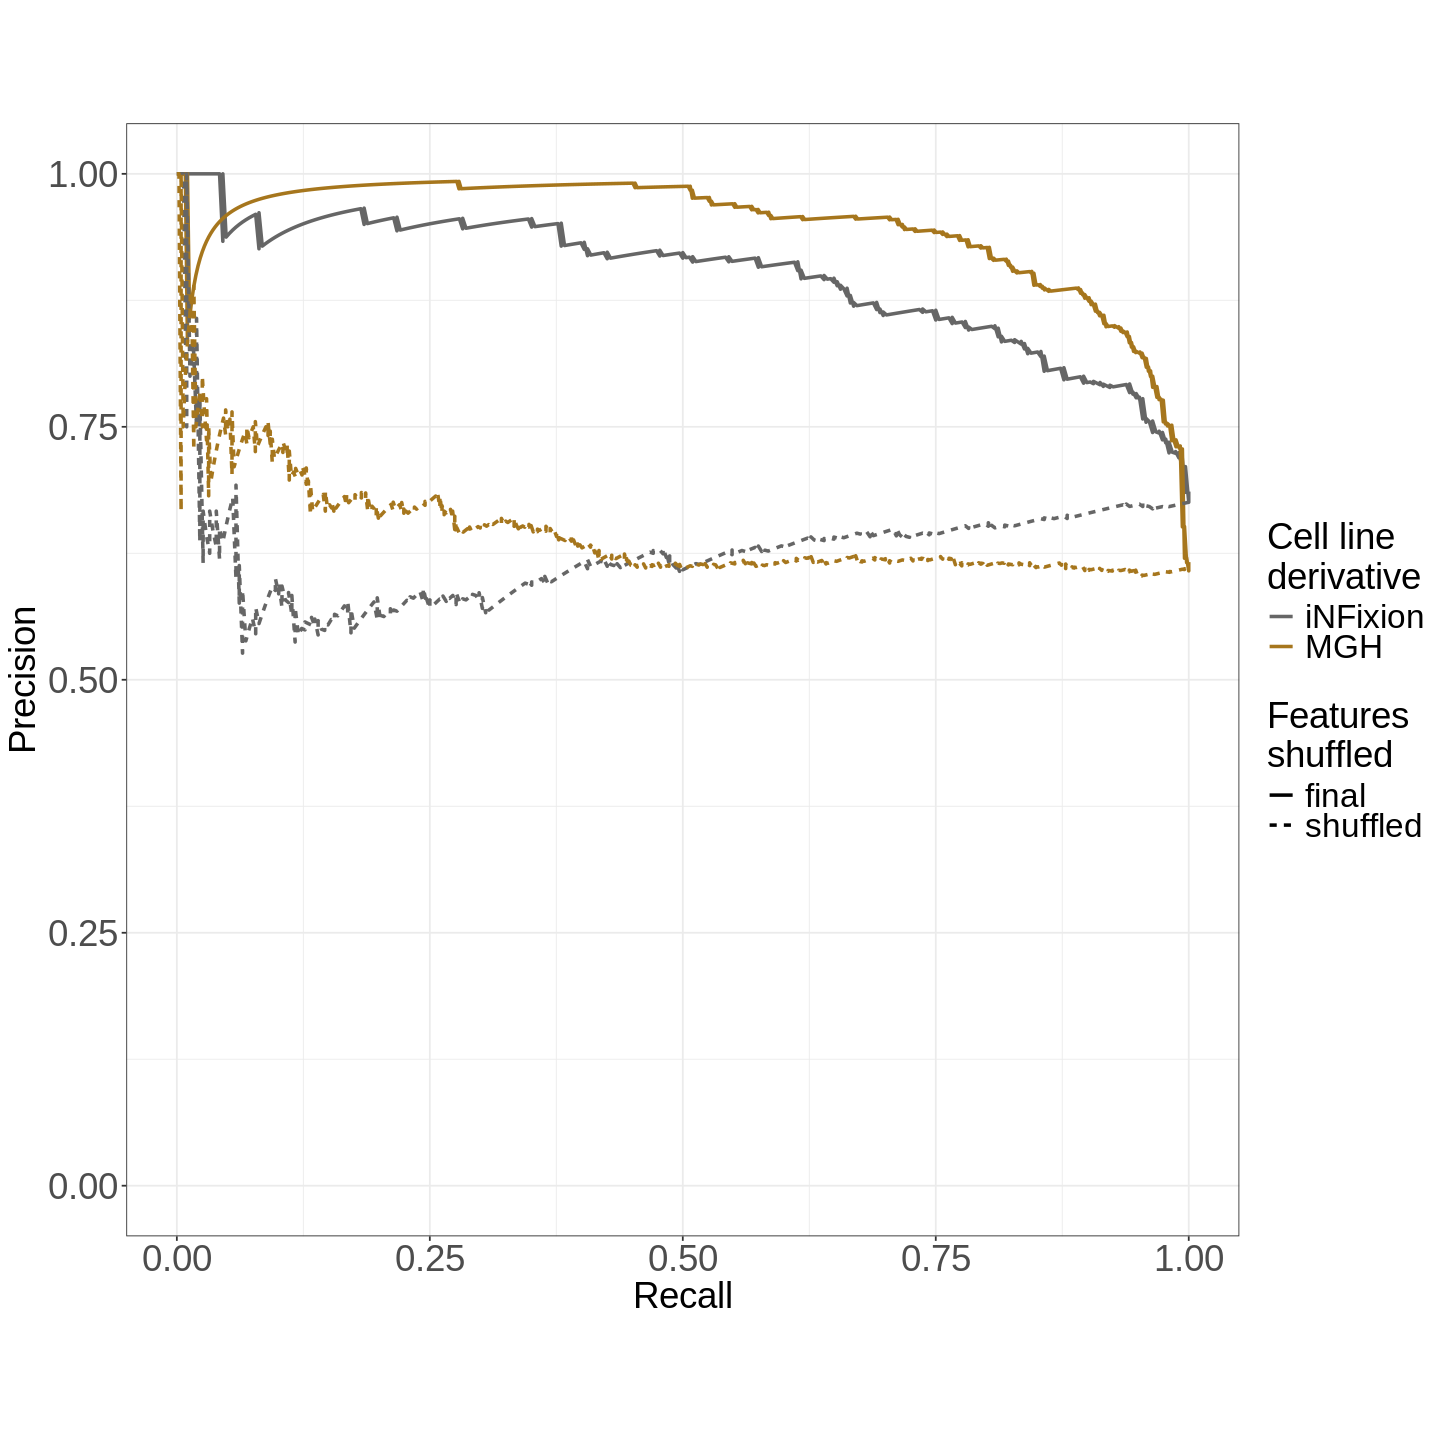

In [8]:
width <- 12
height <- 12
options(repr.plot.width = width, repr.plot.height = height)
pr_plate6_derivative_plot <- (
    ggplot(PR_results_df, aes(x = recall, y = precision, color = institution, linetype = model))
    + geom_line(aes(linetype = model), linewidth = 1)
    + theme_bw()
    + coord_fixed()
    + labs(color = "Cell line\nderivative", linetype = "Features\nshuffled", x = "Recall", y = "Precision")
    # change the colors
    + scale_color_manual(values = c(
        "MGH" = brewer.pal(8, "Dark2")[7],
        "iNFixion" = brewer.pal(8, "Dark2")[8]
    ))
    + scale_y_continuous(limits = c(0, 1))
    # change the line thickness of the lines in the legend
    + guides(linetype = guide_legend(override.aes = list(size = 1)))  
    # change the text size
    + theme(
        # x and y axis text size
        axis.text.x = element_text(size = 22),
        axis.text.y = element_text(size = 22),
        # x and y axis title size
        axis.title.x = element_text(size = 22),
        axis.title.y = element_text(size = 22),
        # legend text size
        legend.text = element_text(size = 20),
        legend.title = element_text(size = 22),
    )
)

pr_plate6_derivative_plot

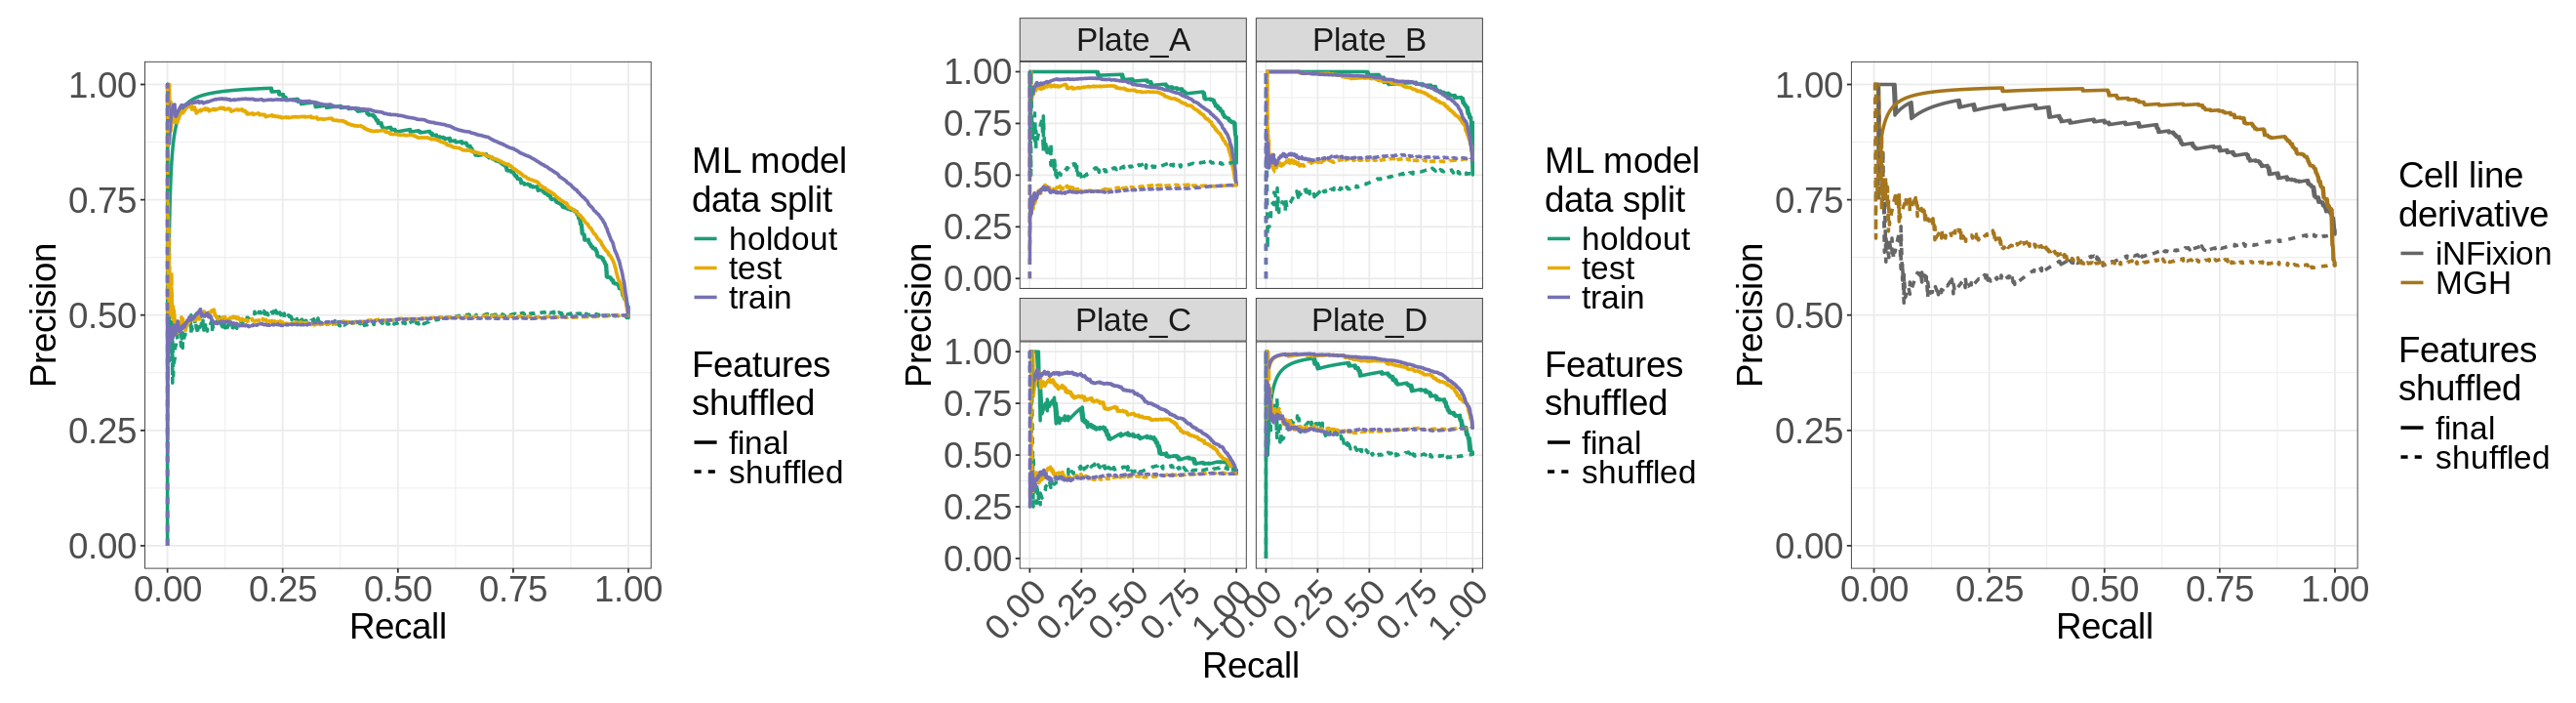

In [9]:
width <- 22
height <- 6
options(repr.plot.width = width, repr.plot.height = height)

align_plot <- 
    pr_train_test_plot + 
    pr_per_plate_plot + 
    pr_plate6_derivative_plot +
    plot_layout(widths = c(1,1,1))

align_plot

In [10]:
supp_fig_7_gg <- (
  align_plot + plot_annotation(tag_levels = list(c("A", "B", "C"))) &
  theme(plot.tag = element_text(size = 30))
)

# Save or display the plot
ggsave(output_supp_figure_7, plot = supp_fig_7_gg, dpi = 500, height = height, width = width)